In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
Ks = np.load("FIP35-Ks.npy")
lag_times = range(1, 151)
basis_list = np.array([[[-0.5402968893832484, 2], [1.6977050721019225, 2]], [[0.03775098344108225, 2], [-0.11639949878185235, 2]], [[0.011024319620013722, 2], [-0.031054131813476105, 2]]])
print(Ks.shape)

(150, 27, 27)


Time = 1 ps
[884.5830807807279, 31.181579554378246, 22.20279682896013, 13.024507774921009, 7.134193485835673]
Time = 2 ps
[1453.427491564388, 51.43970777635894, 35.97308571645774, 19.951670309157734, 11.933718107010055]
Time = 3 ps
[1942.144453514789, 68.94568614921461, 47.279180747810884, 24.96018621517953, 15.925201756782716]
Time = 4 ps
[2363.705711769844, 84.00086705798503, 57.239854100989994, 28.81976574748394, 19.53637468239075]
Time = 5 ps
[2749.1953358175315, 97.8907878219008, 65.65186703568261, 32.18208254581841, 23.030714005316174]
Time = 6 ps
[3099.034210090534, 110.09140721187703, 73.64450036655535, 34.97248946499929, 26.26995203316263]
Time = 7 ps
[3410.9419601364116, 121.72594877057587, 80.14614881723301, 37.27301019064146, 29.307016912229496]
Time = 8 ps
[3707.640968369157, 132.8428188329109, 86.27140291649224, 39.296638632563955, 31.903746243682782]
Time = 9 ps
[3975.6487932032824, 143.68810585483791, 91.92578790395976, 41.156299946687554, 34.62986791391017]
Time = 10 p

ITS.shape = (5, 150)


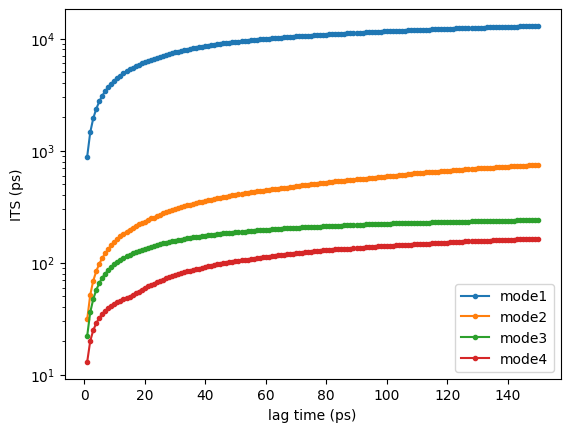

Current date and time: 2026-03-20 13:19:02.734499


In [3]:
ITSs, Es, Vs = [], [], []
for i in range(len(lag_times)):
    evK, vrK = np.linalg.eig(Ks[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", lag_times[i], 'ps')
    ITSs.append([-lag_times[i]/np.log(Es[-1][j]) for j in range(1,6)])
    print(ITSs[-1])

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (ps)")
plt.ylabel("ITS (ps)")

ITS = np.array(ITSs).T
print("ITS.shape =", ITS.shape)
for i in range(4):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [3]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


# regression: tau_k&L, RMSE

In [4]:
def compute_rmse(diff):
    return np.sqrt(np.square(np.mean(diff)) + np.square(np.std(diff)))


In [16]:
def compute_rmse(diff):
    return np.sqrt(np.square(np.mean(diff)) + np.square(np.std(diff)))

RMSE_rec = np.array([[-1.] * 100 for _ in range(100)])
list_plot = [[], [], []]

rmse_steps = 75
for st in range(1, 61):
    for en in range(st+5, 70):
        M_hat, info = fit_M_from_K_sequence(Ks[:en], st, 1, enforce_hermitian_M=False)
        #print_regression_summary(info)
        A_hat = fit_A_from_K0_and_M(Ks[st], M_hat)
        Ks_model = generate_K_from_A_M(A_hat, M_hat, rmse_steps+en-st)
        
        RMSE_rec[st][en] = compute_rmse(Ks_model[en-st:]-Ks[en:rmse_steps+en])
        list_plot[0].append(st)
        list_plot[1].append(en-st)
        list_plot[2].append(RMSE_rec[st][en])
        # Optional: uncertainties
        #Ms_boot, M_mean, M_std = bootstrap_M(Ks, n_boot=200, random_state=0)


In [17]:
arr = np.array(list_plot[2])
idx = np.unravel_index(np.argmin(arr), arr.shape)[0]
print(idx, list_plot[2][idx])
print(list_plot[0][idx], list_plot[1][idx])

1845 0.002862148366259831
43 23


In [18]:
print(len(list_plot[2]))
print(np.min(list_plot[2]), np.max(list_plot[2]))

2070
0.002862148366259831 0.029660540733965294


In [19]:
A = np.array(list_plot[2])
thr = np.percentile(A, 5)

idx = np.where(A <= thr)
print(idx[0])
print([(list_plot[0][_],list_plot[1][_]) for _ in idx[0]])

[1513 1515 1517 1578 1580 1582 1670 1696 1698 1700 1723 1725 1726 1727
 1743 1747 1748 1749 1750 1751 1752 1753 1754 1774 1776 1777 1778 1797
 1798 1799 1800 1801 1802 1803 1821 1822 1823 1824 1825 1826 1837 1840
 1841 1842 1843 1844 1845 1846 1847 1848 1858 1862 1863 1864 1865 1866
 1867 1868 1869 1884 1885 1886 1887 1888 1889 1904 1905 1907 1908 1921
 1922 1923 1924 1925 1926 1937 1938 1939 1940 1941 1942 1943 1953 1954
 1955 1956 1957 1958 1959 1971 1973 1974 1984 1987 1988 1997 2000 2001
 2012 2013 2023 2024 2033 2034]
[(31, 33), (31, 35), (31, 37), (33, 31), (33, 33), (33, 35), (36, 30), (37, 27), (37, 29), (37, 31), (38, 26), (38, 28), (38, 29), (38, 30), (39, 19), (39, 23), (39, 24), (39, 25), (39, 26), (39, 27), (39, 28), (39, 29), (39, 30), (40, 24), (40, 26), (40, 27), (40, 28), (41, 22), (41, 23), (41, 24), (41, 25), (41, 26), (41, 27), (41, 28), (42, 22), (42, 23), (42, 24), (42, 25), (42, 26), (42, 27), (43, 15), (43, 18), (43, 19), (43, 20), (43, 21), (43, 22), (43, 23), 

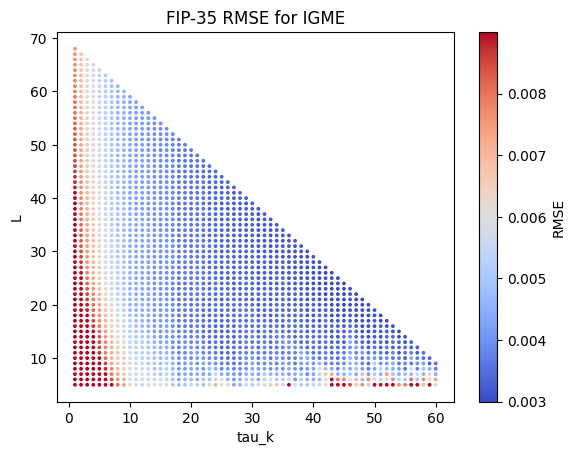

In [22]:
import matplotlib.colors as colors

norm = colors.TwoSlopeNorm(vmin=.003, vcenter=.006, vmax=.009)
plt.scatter(list_plot[0], list_plot[1], s=3, c=list_plot[2], cmap="coolwarm", norm=norm)
plt.colorbar(label='RMSE')
plt.xlabel('tau_k')
plt.ylabel('L')
plt.title('FIP-35 RMSE for IGME')
plt.show()

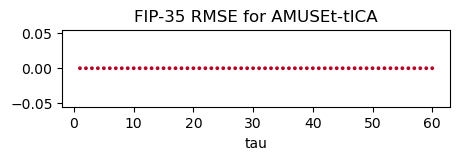

0.04432846515579943 0.06688163901851438


In [11]:
rmse_steps = 75
rmse_AT = []
for i in range(1, 61):
    ed = int(rmse_steps/i)
    this_Ks_seq = [Ks[i]]
    orig_Ks_seq = [Ks[i]]
    for j in range(ed):
        this_Ks_seq.append(Ks[i] @ this_Ks_seq[-1])
        orig_Ks_seq.append(Ks[j*i])
    this_rmse = ((np.mean((np.array(this_Ks_seq)-np.array(orig_Ks_seq))**2))**0.5)
    rmse_AT.append(this_rmse)
    
plt.figure(figsize=(5,1))
norm = colors.TwoSlopeNorm(vmin=.003, vcenter=.006, vmax=.009)
plt.scatter(range(1, 61), [0]*60, s=3, c=rmse_AT, cmap="coolwarm", norm=norm)
plt.xlabel('tau')
plt.title('FIP-35 RMSE for AMUSEt-tICA')
plt.show()
print(np.min(rmse_AT), np.max(rmse_AT))

In [24]:
list_plot = np.array(list_plot)
norm_lim = [.003, .006, .009]
usage = '''norm = colors.TwoSlopeNorm(vmin=.003, vcenter=.006, vmax=.009)
plt.scatter(data[0], data[1], s=3, c=data[2], cmap="coolwarm", norm=norm)
plt.colorbar(label='RMSE')
plt.xlabel('tau_k')
plt.ylabel('L')
plt.title('FIP-35 RMSE for IGME')
plt.show()'''

In [25]:
np.savez('Panel_2a1_RMSE.npz', data=list_plot, norm=norm_lim, title='FIP-35 RMSE for IGME', usage = usage)

In [8]:
norm_lim = [.003, .006, .009]
AT_usage = '''plt.figure(figsize=(5,1))
norm = colors.TwoSlopeNorm(vmin=.003, vcenter=.006, vmax=.009)
plt.scatter(range(1, 61), [0]*60, s=3, c=data, cmap="coolwarm", norm=norm)
plt.xlabel('tau')
plt.title('FIP-35 RMSE for AMUSEt-tICA')
plt.show()'''

np.savez('Panel_2a2_RMSE.npz', data=rmse_AT, norm=norm_lim, title='FIP-35 RMSE for AMUSEt-tICA', usage = AT_usage)

# CVs v.s. RMSD

In [27]:
sub_sam = 5

rmsd1 = []
for i in range(25+33):
    if i < 25:
        txt_name = f"rmsd-beta1\\GTT-0-c-alpha-{i:03d}.txt"
    else:
        txt_name = f"rmsd-beta1\\GTT-1-c-alpha-{i-25:03d}.txt"
    data = np.loadtxt(txt_name)
    rmsd1.append(data[::sub_sam, 1])
    print(f'{i} [{rmsd1[-1].shape}]', end='')
    if i % 8 == 0 and i != 0:
        print()

print('#')

rmsd2 = []
for i in range(25+33):
    if i < 25:
        txt_name = f"rmsd-beta2\\GTT-0-c-alpha-{i:03d}.txt"
    else:
        txt_name = f"rmsd-beta2\\GTT-1-c-alpha-{i-25:03d}.txt"
    data = np.loadtxt(txt_name)
    rmsd2.append(data[::sub_sam, 1])
    print(f'{i} [{rmsd2[-1].shape}]', end='')
    if i % 8 == 0 and i != 0:
        print()


0 [(20000,)]1 [(20000,)]2 [(20000,)]3 [(20000,)]4 [(20000,)]5 [(20000,)]6 [(20000,)]7 [(20000,)]8 [(20000,)]
9 [(20000,)]10 [(20000,)]11 [(20000,)]12 [(20000,)]13 [(20000,)]14 [(20000,)]15 [(20000,)]16 [(20000,)]
17 [(20000,)]18 [(20000,)]19 [(20000,)]20 [(20000,)]21 [(20000,)]22 [(20000,)]23 [(20000,)]24 [(6518,)]
25 [(20000,)]26 [(20000,)]27 [(20000,)]28 [(20000,)]29 [(20000,)]30 [(20000,)]31 [(20000,)]32 [(20000,)]
33 [(20000,)]34 [(20000,)]35 [(20000,)]36 [(20000,)]37 [(20000,)]38 [(20000,)]39 [(20000,)]40 [(20000,)]
41 [(20000,)]42 [(20000,)]43 [(20000,)]44 [(20000,)]45 [(20000,)]46 [(20000,)]47 [(20000,)]48 [(20000,)]
49 [(20000,)]50 [(20000,)]51 [(20000,)]52 [(20000,)]53 [(20000,)]54 [(20000,)]55 [(20000,)]56 [(20000,)]
57 [(10826,)]#
0 [(20000,)]1 [(20000,)]2 [(20000,)]3 [(20000,)]4 [(20000,)]5 [(20000,)]6 [(20000,)]7 [(20000,)]8 [(20000,)]
9 [(20000,)]10 [(20000,)]11 [(20000,)]12 [(20000,)]13 [(20000,)]14 [(20000,)]15 [(20000,)]16 [(20000,)]
17 [(20000,)]18 [(20000,)]19 [(2000

In [28]:
rmsd1 = np.hstack(rmsd1)
rmsd2 = np.hstack(rmsd2)
len(rmsd1), len(rmsd2)

(1137344, 1137344)

In [29]:
basis_list, basis_list.shape

(array([[[-0.54029689,  2.        ],
         [ 1.69770507,  2.        ]],
 
        [[ 0.03775098,  2.        ],
         [-0.1163995 ,  2.        ]],
 
        [[ 0.01102432,  2.        ],
         [-0.03105413,  2.        ]]]),
 (3, 2, 2))

In [30]:
# if using the saved data, skip to the CVs_ generation box
using_saved_data = True
Vt = np.load("FIP35-dim27-SVD-Vt.npy")
Vt.shape

(27, 1137344)

In [3]:
if not using_saved_data:
    load_data_from_npz = np.load("FIP35-tICA.npz")
    tics_of_trajs = np.concatenate([load_data_from_npz['GTT0'], load_data_from_npz['GTT1']], axis=0)
    print(tics_of_trajs.shape)

(1137344, 3)


In [10]:
if not using_saved_data:
    psi_all = []
    for t in range(tics_of_trajs.shape[0]):
        psi_t = [1.0] + [np.exp(- (tics_of_trajs[t][0] - basis_list[0][j][0])**2 / (2 * basis_list[0][j][1]**2))
                         for j in range(len(basis_list[0]))]
        for i in range(1, len(basis_list)):
            phi_temp = [1.0] + [np.exp(- (tics_of_trajs[t][i] - basis_list[i][j][0])**2 / (2 * basis_list[i][j][1]**2))
                         for j in range(len(basis_list[i]))]
            psi_t = np.kron(psi_t, phi_temp)
        psi_all.append(psi_t)

    Psi = np.stack(psi_all, axis=1)
    Psi.shape

In [11]:
if not using_saved_data:
    U, S, Vt = np.linalg.svd(Psi, full_matrices=False)
Vt.shape

(27, 1137344)

In [12]:
#np.save("FIP35-dim27-SVD-Vt.npy", Vt)
# frame gap = 1ps

In [36]:
K_hat, info = fit_M_from_K_sequence(Ks[:67], 42, 1, enforce_hermitian_M=False)

K_e, K_v = np.linalg.eig(K_hat)
idx = np.argsort(K_e)[::-1]
K_e = K_e[idx]
K_v = K_v[:,idx]

CVs_Khat = np.matmul(K_v[:, :5].T, Vt)
print(K_e[:10])
print(-1.0/np.log(K_e[1:10])) # multiply by lag_time

[1.         0.99993667 0.99908276 0.99729397 0.99602784 0.99446936
 0.99384811 0.99209468 0.99113598 0.99050206]
[15790.25065741  1089.72973875   369.04514804   251.25162091
   180.3103035    162.05125414   125.99636674   112.3149019
   104.78515591]


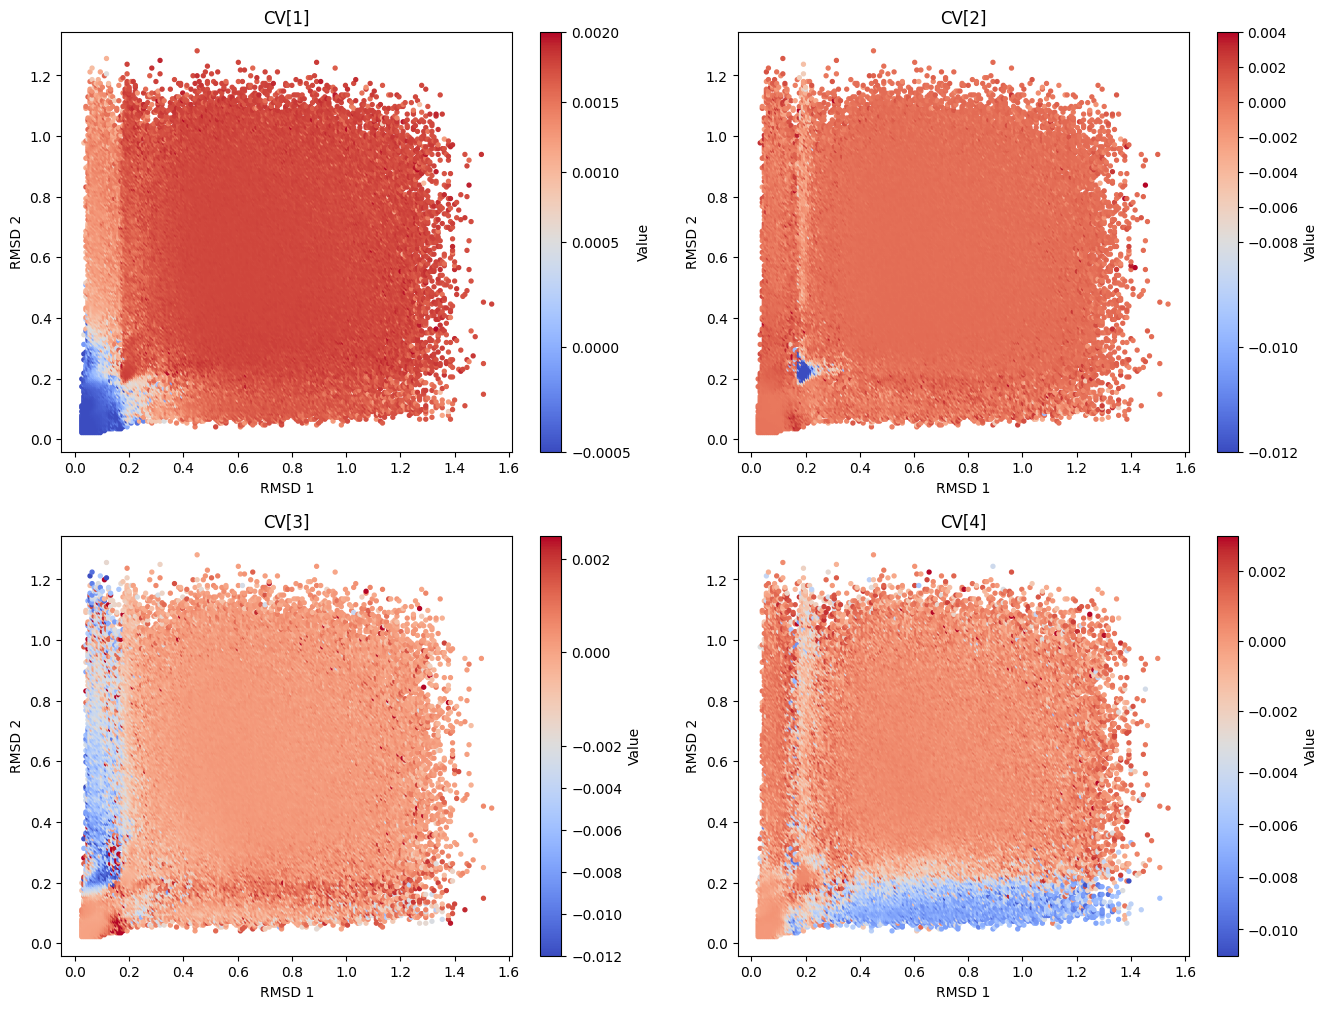

In [37]:
from scipy.stats import binned_statistic_2d

nx, ny = 200, 200
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, ax in enumerate(axes.ravel()):
    CVi = np.real(CVs_Khat[i+1])
    
    z_mean, x_edges, y_edges, _ = binned_statistic_2d(
        rmsd1, rmsd2, CVi, statistic="mean", bins=[nx, ny]
    )

    mask = ~np.isnan(z_mean)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="ij")
    sign = -1 if np.nanmean(z_mean[-100:,-100:])<0 else 1 # always make upper-right corner red
    
    if i == 0:
        norm = colors.TwoSlopeNorm(vmin=-.0005, vcenter=.0005, vmax=.002)
        sc = ax.scatter(Xc[mask], Yc[mask], c=sign*z_mean[mask], s=8, cmap="coolwarm", norm=norm)
    elif i == 1:
        norm = colors.TwoSlopeNorm(vmin=-.012, vcenter=-.008, vmax=.004)
        sc = ax.scatter(Xc[mask], Yc[mask], c=sign*z_mean[mask], s=8, cmap="coolwarm", norm=norm)
    elif i == 2:
        norm = colors.TwoSlopeNorm(vmin=-.012, vcenter=-.002, vmax=.0025)
        sc = ax.scatter(Xc[mask], Yc[mask], c=sign*z_mean[mask], s=8, cmap="coolwarm", norm=norm)
    elif i == 3:
        norm = colors.TwoSlopeNorm(vmin=-.011, vcenter=-.003, vmax=.003)
        sc = ax.scatter(Xc[mask], Yc[mask], c=sign*z_mean[mask], s=8, cmap="coolwarm", norm=norm)
    else:
        sc = ax.scatter(Xc[mask], Yc[mask], c=sign*z_mean[mask], s=8, cmap="coolwarm")
    ax.set_xlabel("RMSD 1")
    ax.set_ylabel("RMSD 2")
    ax.set_title(f"CV[{i+1}]")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Value")

    #     arr[np.isnan(arr)] = -10
    
plt.show()

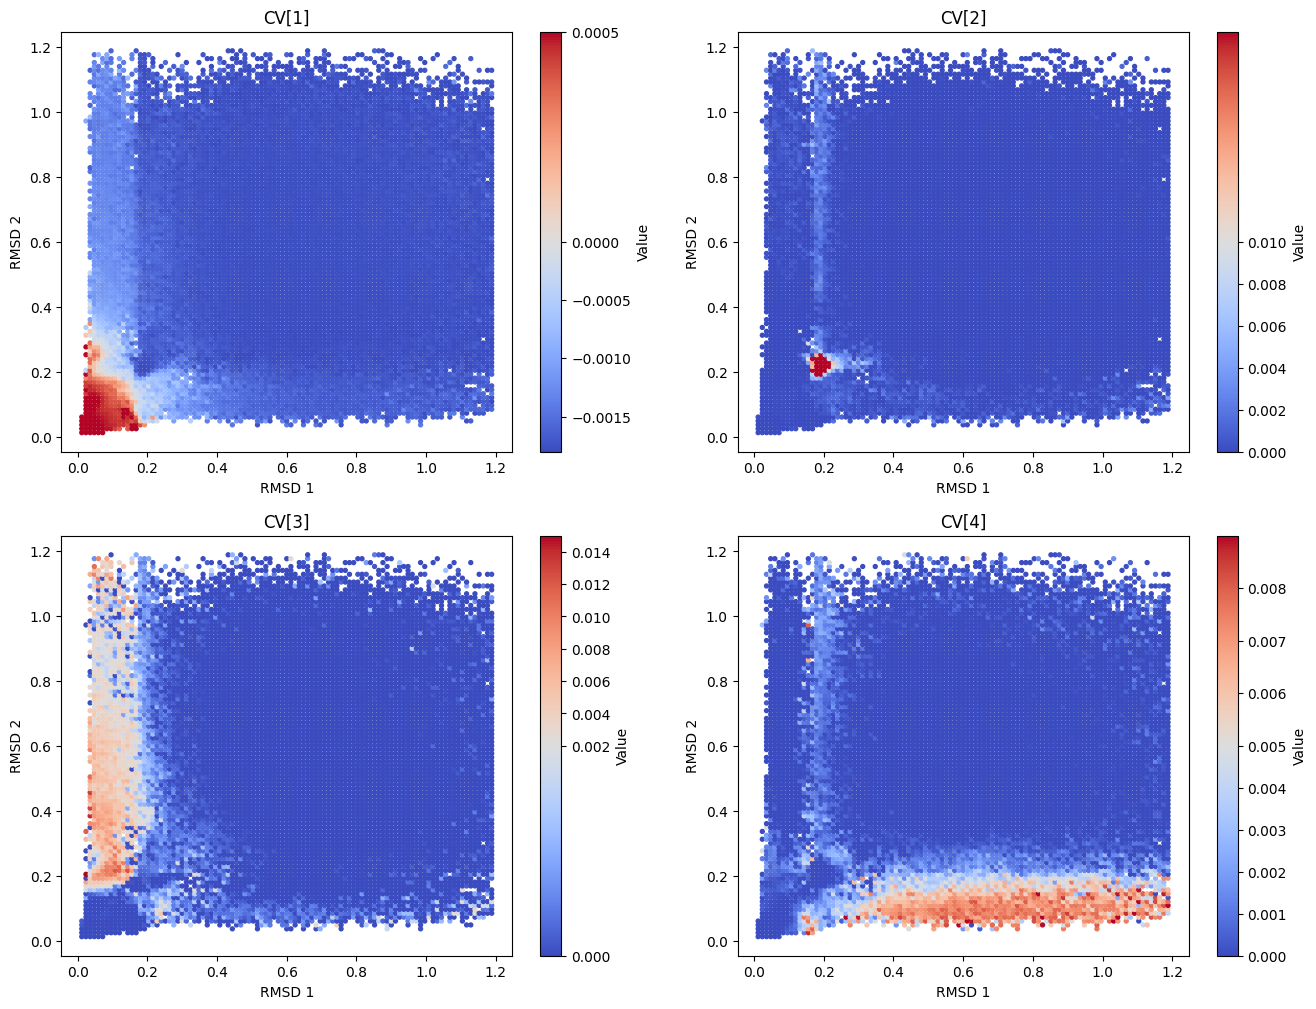

In [39]:
nx, ny = 100, 100
xmax, xmin, ymax, ymin = 1.2, 0., 1.2, 0. 

vmin = [-.0018, 0, 0, 0]
vmean = [0, .01, .002, .005]
vmax = [.0005, .011, .015, .009]

plots_save = []
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x_centers = np.arange(xmin, xmax, (xmax-xmin)/nx)
y_centers = np.arange(ymin, ymax, (ymax-ymin)/ny)
Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="ij")

for i, ax in enumerate(axes.ravel()):
    CVi = np.real(CVs_Khat[i+1])
    
    z_count, z_value_sum = np.zeros((nx,ny), dtype=int), np.zeros((nx,ny), dtype=np.float32)
    for j in range(len(CVi)):
        if xmin <= rmsd1[j] < xmax and ymin <= rmsd2[j] < ymax:
            x_pos = int((rmsd1[j] - xmin) / (xmax - xmin) * nx)
            y_pos = int((rmsd2[j] - ymin) / (ymax - ymin) * ny)
            z_count[x_pos][y_pos] += 1
            z_value_sum[x_pos][y_pos] += CVi[j]

    z_plot = np.zeros((nx,ny), dtype=np.float32)
    for x_idx in range(nx):
        for y_idx in range(ny):
            z_plot[x_idx][y_idx] = np.nan if z_count[x_idx][y_idx] == 0 else z_value_sum[x_idx][y_idx] / z_count[x_idx][y_idx]
    
    mask = ~np.isnan(z_plot)
    
    sign = -1 if i == 1 or i == 3 else 1
    z_plot = sign*z_plot
    norm = colors.TwoSlopeNorm(vmin=vmin[i], vcenter=vmean[i], vmax=vmax[i])
    sc = ax.scatter(Xc[mask], Yc[mask], c=z_plot[mask], s=8, cmap="coolwarm", norm=norm)
    ax.set_xlabel("RMSD 1")
    ax.set_ylabel("RMSD 2")
    ax.set_title(f"CV[{i+1}]")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Value")
    
    plots_save.append(z_plot)
    
plt.show()


In [41]:
st, en = 42, 67
final = 300

K_hat, info = fit_M_from_K_sequence(Ks[:en], st, 1, enforce_hermitian_M=False)
K_pred_final = np.matmul(Ks[en-1], np.linalg.matrix_power(K_hat, final-en))

K_e, K_v = np.linalg.eig(K_pred_final)
idx = np.argsort(K_e)[::-1]
K_e = K_e[idx]
K_v = K_v[:,idx]

CVs_Khat = np.matmul(K_v[:, :5].T, Vt)
print(K_e[:10])
print(-1.0*final/np.log(K_e[1:10])) # multiply by lag_time

[1.         0.97879385 0.69234706 0.35111734 0.21387201 0.11207597
 0.05295857 0.038864   0.03440747 0.02809959]
[13996.30649604   815.9537188    286.63292885   194.50490599
   137.07528641   102.10175448    92.37343832    89.03446647
    83.98655213]


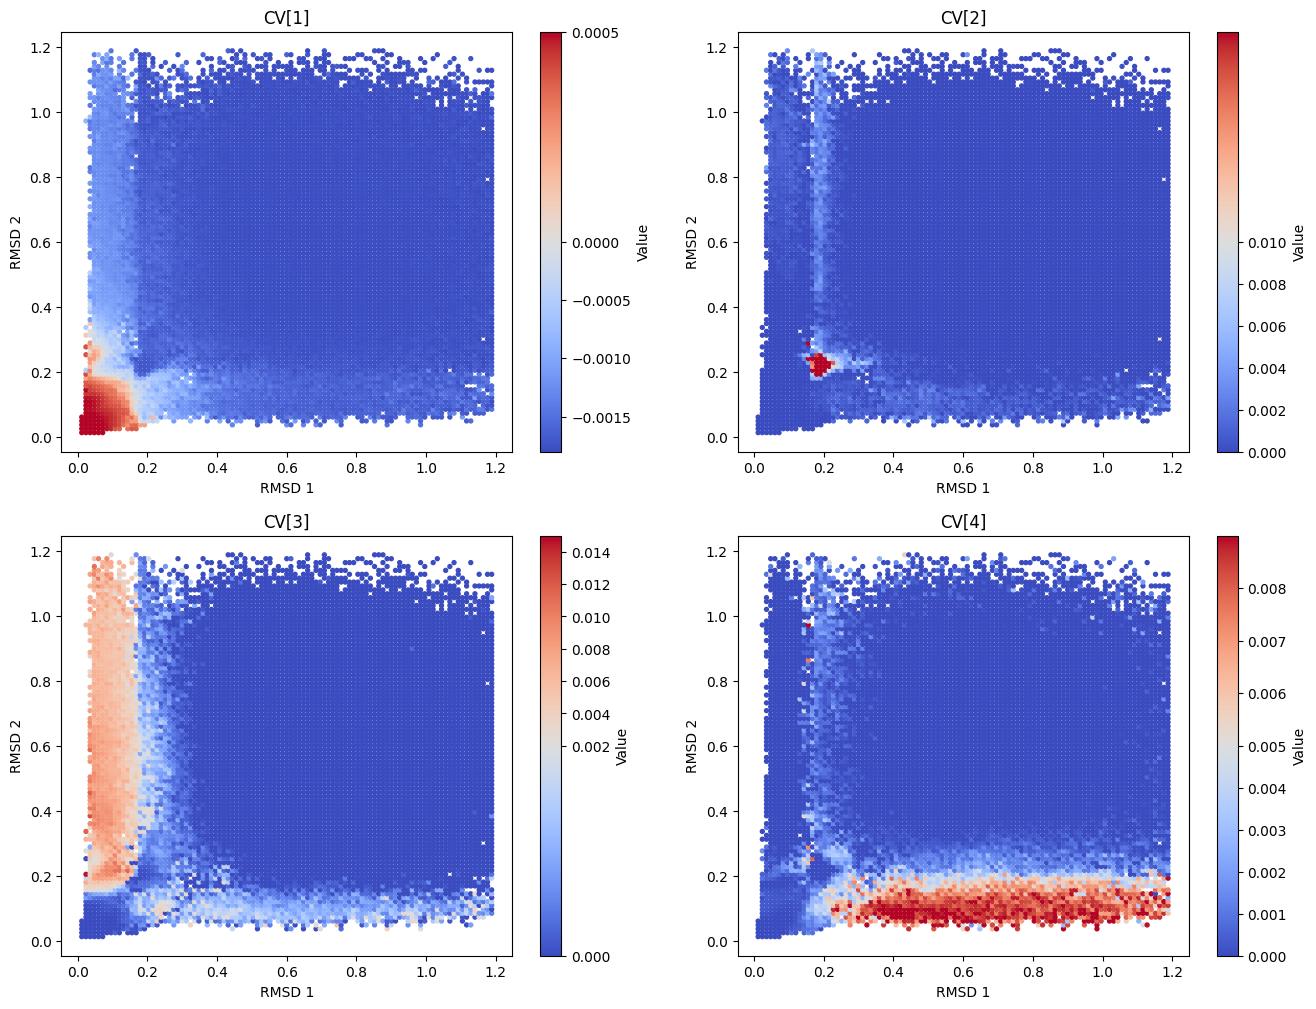

In [43]:
nx, ny = 100, 100
xmax, xmin, ymax, ymin = 1.2, 0., 1.2, 0. 

vmin = [-.0018, 0, 0, 0]
vmean = [0, .01, .002, .005]
vmax = [.0005, .011, .015, .009]

plots_save = []
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x_centers = np.arange(xmin, xmax, (xmax-xmin)/nx)
y_centers = np.arange(ymin, ymax, (ymax-ymin)/ny)
Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="ij")

for i, ax in enumerate(axes.ravel()):
    CVi = np.real(CVs_Khat[i+1])
    
    z_count, z_value_sum = np.zeros((nx,ny), dtype=int), np.zeros((nx,ny), dtype=np.float32)
    for j in range(len(CVi)):
        if xmin <= rmsd1[j] < xmax and ymin <= rmsd2[j] < ymax:
            x_pos = int((rmsd1[j] - xmin) / (xmax - xmin) * nx)
            y_pos = int((rmsd2[j] - ymin) / (ymax - ymin) * ny)
            z_count[x_pos][y_pos] += 1
            z_value_sum[x_pos][y_pos] += CVi[j]

    z_plot = np.zeros((nx,ny), dtype=np.float32)
    for x_idx in range(nx):
        for y_idx in range(ny):
            z_plot[x_idx][y_idx] = np.nan if z_count[x_idx][y_idx] == 0 else z_value_sum[x_idx][y_idx] / z_count[x_idx][y_idx]
    
    mask = ~np.isnan(z_plot)
    
    sign = -1 if i != 2 else 1
    z_plot = sign*z_plot
    norm = colors.TwoSlopeNorm(vmin=vmin[i], vcenter=vmean[i], vmax=vmax[i])
    sc = ax.scatter(Xc[mask], Yc[mask], c=z_plot[mask], s=8, cmap="coolwarm", norm=norm)
    ax.set_xlabel("RMSD 1")
    ax.set_ylabel("RMSD 2")
    ax.set_title(f"CV[{i+1}]")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Value")
    
    plots_save.append(z_plot)
    
plt.show()


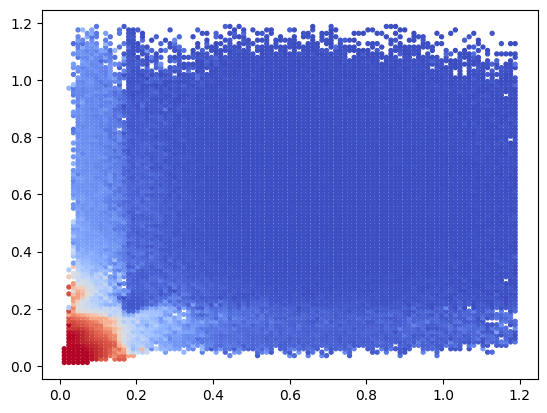

CV[1] done


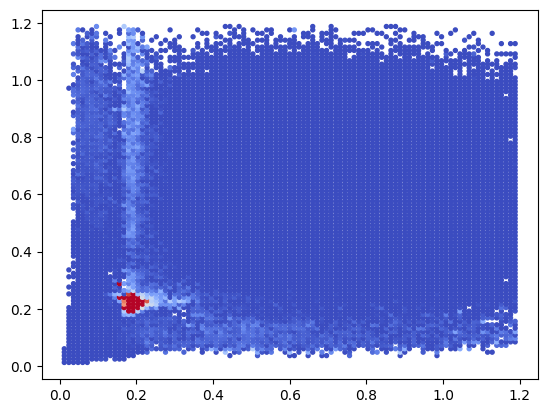

CV[2] done


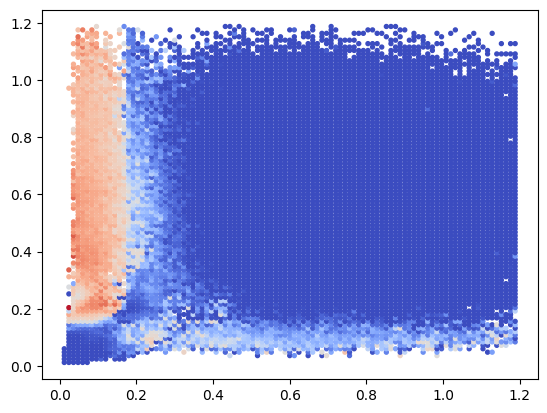

CV[3] done


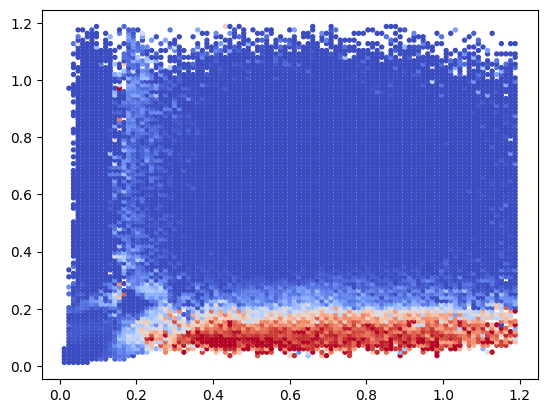

CV[4] done


In [44]:
x_out = Xc.reshape((-1))
y_out = Yc.reshape((-1))

for i in range(len(plots_save)):
    data_output = plots_save[i].reshape((-1))
    with open(f"FIP35_pred300lag-mode{i+1}_color.txt", "w") as f:
        f.write(f"-10 255 255 255\n")
        f.write(f"{np.nanmin(data_output)} 0 0 160\n")
        f.write(f"{vmin[i]} 0 0 255\n")
        f.write(f"{vmean[i]} 255 255 255\n")
        f.write(f"{vmax[i]} 255 0 0\n")
        f.write(f"{np.nanmax(data_output)} 160 0 0\n")
    np.nan_to_num(data_output, nan=-10, copy=False)
    with open(f"FIP35_pred300lag-mode{i+1}_data.txt", "w") as f:
        mask = data_output == -10
        norm = colors.TwoSlopeNorm(vmin=vmin[i], vcenter=vmean[i], vmax=vmax[i])
        plt.scatter(x_out[~mask], y_out[~mask], c=data_output[~mask], s=8, cmap="coolwarm", norm=norm)
        plt.show()
        for j in range(len(data_output)):
            f.write(f"{x_out[j]:.3f} {y_out[j]:.3f} {data_output[j]:.10f}\n")
    
    print(f"CV[{i+1}] done")

